# PflegeOptix - Sprint 3 (Part 2): PuLP Optimization (Bed Allocation)

This notebook uses Linear Programming (PuLP) to optimally allocate a limited budget of new care beds across all districts in Germany to address the forecasted **Care Gap in 2040**.

This is the second part of Sprint 3, building on top of the XGBoost + SHAP analysis.

## 1. Calculate the Care Gap (2040)
- We use the 2023 current care bed supply as the baseline.
- We use the 2040 forecasted 65+ population (from Prophet in Sprint 2).
- **Care Gap** = (Current Versorgungsquote × Pop_65_2040) − Current Beds 2023

## 2. Optimization Scenario
Suppose the government has a budget to build **20,000 new beds** nationwide.
How should we distribute these 20,000 beds to minimize the worst-case bed deficit across all districts? (Min-Max Fairness Objective)


In [1]:
# Note: PuLP is already installed in the virtual environment.
# If not, run: pip install pulp


In [2]:
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Step 1: Prepare Data & Calculate Care Gap 2040

In [3]:
# 1. Load Current Supply Data (using latest year available, typically 2023)
df_master = pd.read_csv('../../dataset/processed/master_dataset.csv')

# Filter out state aggregates to avoid double counting
numeric_ags = pd.to_numeric(df_master["AGS"], errors="coerce")
df_master = df_master[numeric_ags > 99].copy()

# Get the latest year for each district
latest_year = df_master['Year'].max()
df_current = df_master[df_master['Year'] == latest_year].copy()

# Calculate current Versorgungsquote
df_current['Current_Versorgungsquote'] = df_current['FullStay_Beds'] / df_current['Total']

# Keep only needed columns
df_current = df_current[['AGS', 'Region', 'FullStay_Beds', 'Current_Versorgungsquote']].copy()
df_current.rename(columns={'FullStay_Beds': 'Current_Beds'}, inplace=True)

# 2. Load 2040 Population Forecast (from Sprint 2)
df_forecast = pd.read_csv('../../dataset/processed/population_forecast_2040.csv')
df_2040 = df_forecast[df_forecast['Year'] == 2040].copy()

# Ensure AGS is string for merging
df_current['AGS'] = df_current['AGS'].astype(str).str.zfill(5)
df_2040['AGS'] = df_2040['AGS'].astype(str).str.zfill(5)

# Merge
df = pd.merge(df_current, df_2040[['AGS', 'Pop_Total_Forecast']], on='AGS', how='inner')

# 3. Calculate 2040 Demand and Care Gap
df['Demand_2040'] = df['Current_Versorgungsquote'] * df['Pop_Total_Forecast']
df['Care_Gap'] = df['Demand_2040'] - df['Current_Beds']

# If Care Gap is negative (supply > demand), set deficit to 0
df['Deficit'] = df['Care_Gap'].clip(lower=0)

print(f"Total Districts: {len(df)}")
print(f"Total Nationwide Deficit in 2040: {df['Deficit'].sum():,.0f} beds")
df.sort_values('Deficit', ascending=False).head(10)

Total Districts: 399
Total Nationwide Deficit in 2040: 40,888 beds


,AGS,Region,Current_Beds,Current_Versorgungsquote,Pop_Total_Forecast,Demand_2040,Care_Gap,Deficit
80,05334,"Städteregion Aachen, Kreis",5828.0,0.010006,6.980626e+05,6984.665313,1156.665313,1156.665313
384,16063,Wartburgkreis,2059.0,0.013171,2.305737e+05,3036.774950,977.774950,977.774950
360,14713,"Leipzig, kreisfreie Stadt",6931.0,0.011399,6.780346e+05,7729.206362,798.206362,798.206362
60,04011,"Bremen, kreisfreie Stadt",5519.0,0.009445,6.662719e+05,6292.919873,773.919873,773.919873
25,03241,"Region Hannover, Landkreis",15272.0,0.013409,1.193639e+06,16005.418432,733.418432,733.418432
222,09162,"München, kreisfreie Stadt",7682.0,0.005160,1.604191e+06,8277.850657,595.850657,595.850657
282,09564,"Nürnberg, kreisfreie Stadt",5738.0,0.010896,5.756649e+05,6272.554919,534.554919,534.554919
321,10044,"Saarlouis, Landkreis",2038.0,0.009889,2.553478e+05,2525.056092,487.056092,487.056092
116,06412,"Frankfurt am Main, kreisfreie Stadt",4941.0,0.006592,8.224257e+05,5421.060573,480.060573,480.060573
355,14612,"Dresden, kreisfreie Stadt",6231.0,0.011067,6.045865e+05,6691.032567,460.032567,460.032567


## Step 2: Linear Programming (PuLP) - Fairness Optimization
**Objective:** Allocate `N` new beds across all districts to minimize the maximum unmet deficit ratio (to ensure no district is left too far behind).

In [4]:
TOTAL_NEW_BEDS = 20000  # Budget for 20,000 new beds nationwide

# 1. Initialize PuLP Problem (Minimize the max deficit ratio)
prob = pulp.LpProblem("Bed_Allocation_Fairness", pulp.LpMinimize)

# 2. Decision Variables
districts = df['AGS'].tolist()

# Number of beds to build in each district (integer, >= 0)
build_vars = pulp.LpVariable.dicts("Build", districts, lowBound=0, cat='Integer')

# Max unmet deficit ratio (the variable we want to minimize)
Z = pulp.LpVariable("Z", lowBound=0)

# 3. Objective Function
prob += Z, "Minimize the maximum unmet ratio"

# 4. Constraints

# Constraint A: Total beds built cannot exceed the budget
prob += pulp.lpSum([build_vars[i] for i in districts]) <= TOTAL_NEW_BEDS, "Total Budget Constraint"

# Define Deficit Dictionary
deficit_dict = dict(zip(df['AGS'], df['Deficit']))

# Constraint B: We don't build more beds than a district needs
for i in districts:
    prob += build_vars[i] <= deficit_dict[i], f"Max_Need_{i}"

# Constraint C: Min-Max Fairness formulation
# (Deficit - Build) / Deficit <= Z  --> The unmet ratio must be <= Z
for i in districts:
    if deficit_dict[i] > 0:
        prob += (deficit_dict[i] - build_vars[i]) / deficit_dict[i] <= Z, f"Fairness_{i}"

# 5. Solve the problem
status = prob.solve(pulp.PULP_CBC_CMD(msg=False))
print(f"Optimization Status: {pulp.LpStatus[status]}")

Optimization Status: Optimal


## Step 3: Analyze Results

In [5]:
# Extract Results
results = []
for i in districts:
    built = build_vars[i].varValue
    results.append({'AGS': i, 'Beds_Allocated': built})

df_res = pd.DataFrame(results)
df_final = pd.merge(df, df_res, on='AGS')

df_final['Remaining_Deficit'] = df_final['Deficit'] - df_final['Beds_Allocated']
df_final['Unmet_Ratio'] = np.where(df_final['Deficit'] > 0, df_final['Remaining_Deficit'] / df_final['Deficit'], 0)

print(f"Total Beds Allocated: {df_final['Beds_Allocated'].sum():,.0f}")
print(f"Original Nationwide Deficit: {df_final['Deficit'].sum():,.0f}")
print(f"Remaining Nationwide Deficit: {df_final['Remaining_Deficit'].sum():,.0f}")

# Top 10 districts receiving the most beds
df_final.sort_values('Beds_Allocated', ascending=False).head(10)

Total Beds Allocated: 20,000
Original Nationwide Deficit: 40,888
Remaining Nationwide Deficit: 20,888


,AGS,Region,Current_Beds,Current_Versorgungsquote,Pop_Total_Forecast,Demand_2040,Care_Gap,Deficit,Beds_Allocated,Remaining_Deficit,Unmet_Ratio
80,05334,"Städteregion Aachen, Kreis",5828.0,0.010006,6.980626e+05,6984.665313,1156.665313,1156.665313,562.0,594.665313,0.514120
384,16063,Wartburgkreis,2059.0,0.013171,2.305737e+05,3036.774950,977.774950,977.774950,476.0,501.774950,0.513180
360,14713,"Leipzig, kreisfreie Stadt",6931.0,0.011399,6.780346e+05,7729.206362,798.206362,798.206362,388.0,410.206362,0.513910
60,04011,"Bremen, kreisfreie Stadt",5519.0,0.009445,6.662719e+05,6292.919873,773.919873,773.919873,376.0,397.919873,0.514162
25,03241,"Region Hannover, Landkreis",15272.0,0.013409,1.193639e+06,16005.418432,733.418432,733.418432,357.0,376.418432,0.513238
222,09162,"München, kreisfreie Stadt",7682.0,0.005160,1.604191e+06,8277.850657,595.850657,595.850657,290.0,305.850657,0.513301
282,09564,"Nürnberg, kreisfreie Stadt",5738.0,0.010896,5.756649e+05,6272.554919,534.554919,534.554919,260.0,274.554919,0.513614
321,10044,"Saarlouis, Landkreis",2038.0,0.009889,2.553478e+05,2525.056092,487.056092,487.056092,237.0,250.056092,0.513403
116,06412,"Frankfurt am Main, kreisfreie Stadt",4941.0,0.006592,8.224257e+05,5421.060573,480.060573,480.060573,234.0,246.060573,0.512562
355,14612,"Dresden, kreisfreie Stadt",6231.0,0.011067,6.045865e+05,6691.032567,460.032567,460.032567,224.0,236.032567,0.513078


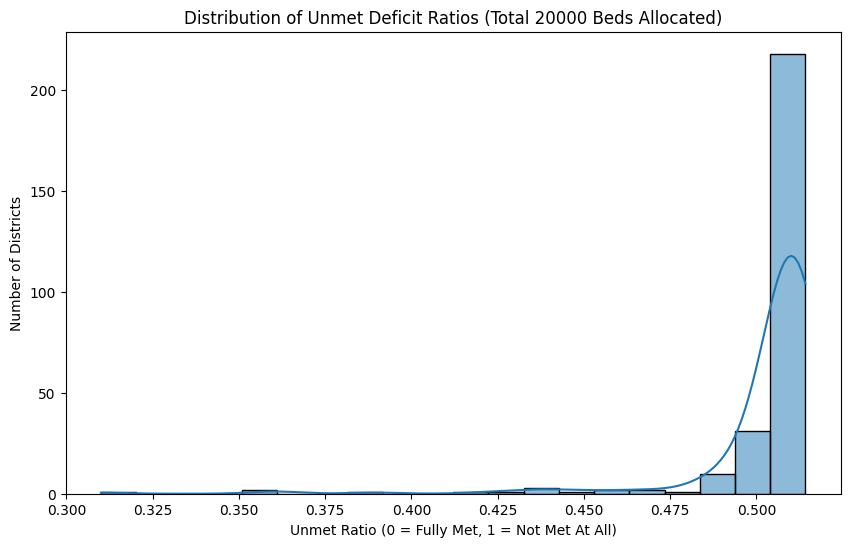

In [6]:
import os
os.makedirs('../../reports/figures', exist_ok=True)

plt.figure(figsize=(10, 6))
sns.histplot(df_final[df_final['Deficit'] > 0]['Unmet_Ratio'], bins=20, kde=True)
plt.title(f"Distribution of Unmet Deficit Ratios (Total {TOTAL_NEW_BEDS} Beds Allocated)")
plt.xlabel("Unmet Ratio (0 = Fully Met, 1 = Not Met At All)")
plt.ylabel("Number of Districts")
plt.savefig('../../reports/figures/pulp_allocation_dist.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Save allocation results for Dashboard (Sprint 4)
import os
output_path = '../../dataset/processed/pulp_allocation_results.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df_final.to_csv(output_path, index=False)
print(f"Allocation results saved to: {output_path}")
print(f"Shape: {df_final.shape}")
print(f"Columns: {df_final.columns.tolist()}")


Allocation results saved to: ../../dataset/processed/pulp_allocation_results.csv
Shape: (399, 11)
Columns: ['AGS', 'Region', 'Current_Beds', 'Current_Versorgungsquote', 'Pop_Total_Forecast', 'Demand_2040', 'Care_Gap', 'Deficit', 'Beds_Allocated', 'Remaining_Deficit', 'Unmet_Ratio']


---
## Summary

### Key Results
- **Total Nationwide Deficit (2040):** ~40,888 beds
- **Budget Allocated:** 20,000 new beds
- **Optimization Method:** Min-Max Fairness (minimize worst-case unmet ratio)
- **Outcome:** All districts with deficit receive proportional allocation

### How It Works
The optimizer ensures **no single district is left disproportionately behind**.
Instead of giving all beds to the worst-off district, it spreads the budget
so that every district's unmet ratio is as equal as possible.

### Output for Dashboard
- `dataset/processed/pulp_allocation_results.csv` — used by Sprint 4 Streamlit app
- The Dashboard will allow users to adjust the budget slider (10k–100k beds)
  and re-run PuLP in real-time to see how allocation changes.

### Next Steps
- **Sprint 4:** Build interactive Streamlit dashboard with budget slider
- **Sprint 5:** Final report and presentation
